In [1]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## To get the current working directory
os.getcwd()

'C:\\Users\\ask2a\\OneDrive\\TRAINING\\INTELLIPAAT\\MACHINE LEARNING\\02.ML_25Jul_2026'

In [3]:
os.listdir()

['.ipynb_checkpoints',
 'AirPassengers.csv',
 'PCA Understanding with small dataset_25July.ipynb',
 'pca.csv',
 'PCA_Sample_Demo.xlsx']

### Let us do `PCA` using a sample data

In [4]:
pca_data = pd.read_csv('pca.csv')
pca_data

,X,Y
0,2.5,2.4
1,0.5,0.7
2,2.2,2.9
3,1.9,2.2
4,3.1,3.0
5,2.3,2.7
6,2.0,1.6
7,1.0,1.1
8,1.5,1.6
9,1.1,0.9


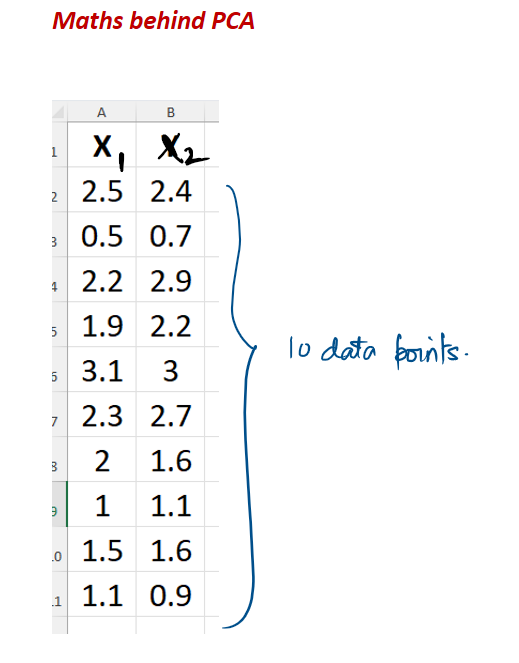

In [6]:
type(pca_data)

pandas.DataFrame

### Let us plot the `original distribution` of the data

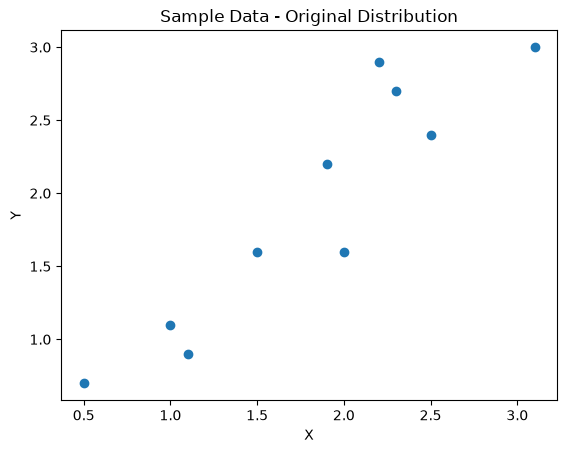

In [7]:
plt.figure()
plt.scatter(pca_data['X'], pca_data['Y'])
plt.title("Sample Data - Original Distribution")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

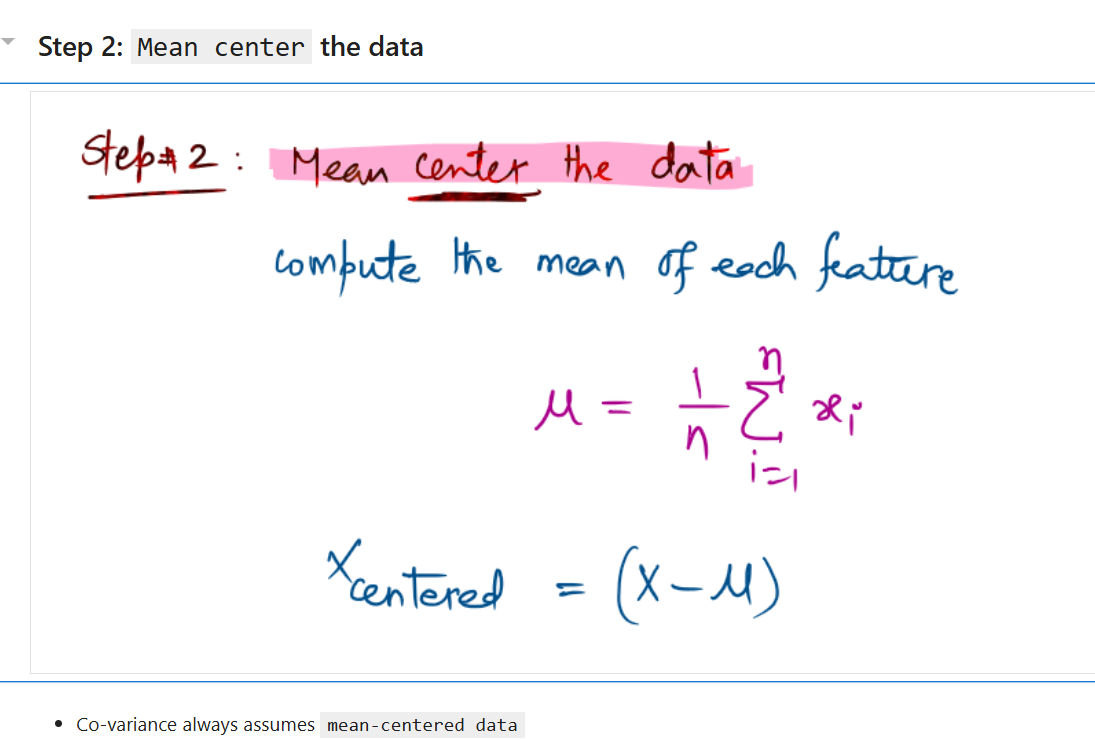

### Step 3: Find the `Covariance Matrix`

- np.cov() - automatically `mean-centers the data internally` before computing covariance

- https://numpy.org/doc/stable/reference/generated/numpy.cov.html

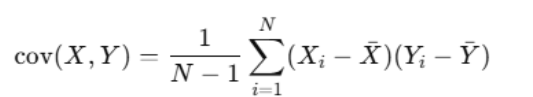

In [8]:
matrix = np.array(pca_data)
matrix

array([[2.5, 2.4],
       [0.5, 0.7],
       [2.2, 2.9],
       [1.9, 2.2],
       [3.1, 3. ],
       [2.3, 2.7],
       [2. , 1.6],
       [1. , 1.1],
       [1.5, 1.6],
       [1.1, 0.9]])

In [9]:
type(matrix)

numpy.ndarray

In [10]:
### Calculate the covariance matrix
cov_matrix = np.cov(matrix[:,0], matrix[:,1])
cov_matrix

array([[0.61655556, 0.61544444],
       [0.61544444, 0.71655556]])

### Step 4: Find `eigen values` & their respective`eigen vectors` for the computed `covariance matrix` from the data

In [11]:
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)
print("Eigen Values:", eigen_values)
print("Eigen Vectors:", eigen_vectors)

Eigen Values: [0.0490834  1.28402771]
Eigen Vectors: [[-0.73517866 -0.6778734 ]
 [ 0.6778734  -0.73517866]]


### TASK: PLOT THE EIGEN VECTORS ON THE ORIGINAL DATA DISTRIBUTION

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

In [13]:
matrix

array([[2.5, 2.4],
       [0.5, 0.7],
       [2.2, 2.9],
       [1.9, 2.2],
       [3.1, 3. ],
       [2.3, 2.7],
       [2. , 1.6],
       [1. , 1.1],
       [1.5, 1.6],
       [1.1, 0.9]])

In [14]:
mean = matrix.mean(axis=0) #finding mean for each of the features
mean

array([1.81, 1.91])

In [17]:
### Create and fit a PCA model
pca = PCA(n_components=2)
pca.fit(matrix)

### Show the eigen values
print("Eigen Values:", pca.explained_variance_)
### Show the respective eigen vectors
print("Eigen Vectors:", pca.components_)

Eigen Values: [1.28402771 0.0490834 ]
Eigen Vectors: [[ 0.6778734   0.73517866]
 [ 0.73517866 -0.6778734 ]]


### Let us plot the original distribution and eigen vectors on top of it

In [18]:
mean

array([1.81, 1.91])

In [26]:
mean1 = mean
mean2 = mean

In [19]:
pc1 = pca.components_[0] #first component
print("First PC:", pc1)

pc2 = pca.components_[1] #second component
print("Second PC:", pc2)

eig1 = pca.explained_variance_[0]#eigen value 1
eig2 = pca.explained_variance_[1]#eigen value 2

## how much variance is captured by different principal components ?
print("Variance captured by PCs:", pca.explained_variance_ratio_*100, "%")

First PC: [0.6778734  0.73517866]
Second PC: [ 0.73517866 -0.6778734 ]
Variance captured by PCs: [96.31813143  3.68186857] %


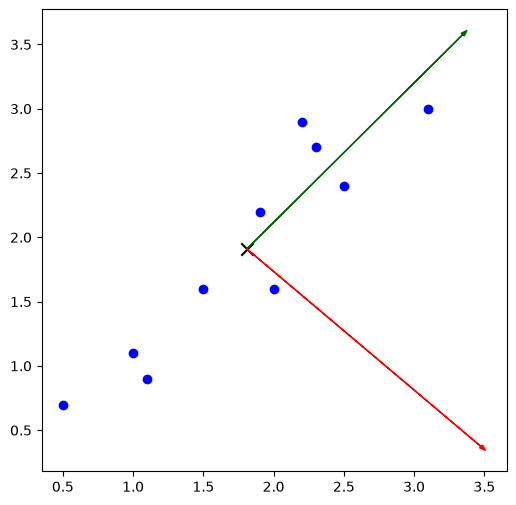

In [40]:
### Setting up the canvas for plotting
plt.figure(figsize = (6,6))

### Original distribution
plt.scatter(matrix[:,0], matrix[:,1], color='blue', label = 'Original Data')#original data distribution

### Let us plot the mean of the data
plt.scatter(mean[0], mean[1], color='black', marker = 'x', s=80, label='Mean - Original Data') #mean-data distribution

### Use this to show overlapping markers
# plt.scatter(mean1[0], mean1[1], color='black', marker='x', s=80, 
#             linewidths=2.5, zorder=5, label='Mean - Original Data')
# plt.scatter(mean2[0], mean2[1], facecolors='none', edgecolors='red', 
#             marker='o', s=200, linewidths=2, zorder=6, label='Mean - Transformed Data')

### let us show first PC - first eigen vector
plt.arrow(
    mean[0], mean[1],
    pc1[0]*np.sqrt(eig1)*2,
    pc1[1]*np.sqrt(eig1)*2,
    color='darkgreen',
    width= 0.001,
    head_width = 0.03,
    label = 'First Principal Component (PC1)'
)


### let us show second PC - second eigen vector
plt.arrow(
    mean[0], mean[1],
    pc2[0]*np.sqrt(eig1)*2,
    pc2[1]*np.sqrt(eig1)*2,
    color='red',
    width= 0.001,
    head_width = 0.03,
    label = 'Second Principal Component (PC1)'
)

plt.show()

#### TASK - Pls run this code at your end and jot down your queries